In [1]:
# ============================================================================
# Standard library imports
# ============================================================================

import warnings
from pathlib import Path
from typing import Dict, List, Optional

# ============================================================================
# Third-party imports
# ============================================================================

# Visualization
import matplotlib.pyplot as plt

# Numerical computing
import numpy as np

# Data manipulation
import pandas as pd

# Econometrics / statistical modeling
import statsmodels.api as sm
from econml.dml import LinearDML
from linearmodels.panel import PanelOLS
from scipy.stats.mstats import winsorize
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Machine learning
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler

# ============================================================================
# Global configuration
# ============================================================================

# Suppress non-critical warnings for cleaner notebook/script output.
warnings.filterwarnings("ignore")

# Ensure reproducibility for stochastic operations.
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

Hybrid Econometric-Machine Learning Pipeline for Inclusive Growth in Indonesia

[DATA LOADING]
Loaded dataset shape: (238, 24)
[VALIDATION] Required columns OK.
[VALIDATION] No duplicate panel keys.

[MISSINGNESS]
                     missing_count  missing_percent
domestic_invest                  1         0.420168
province                         0         0.000000
grdp_employed                    0         0.000000
year                             0         0.000000
health_complaint                 0         0.000000
to                               0         0.000000
formal_sector                    0         0.000000
grdp_capita                      0         0.000000
unemployed_percent               0         0.000000
hdi                              0         0.000000
gov_capex                        0         0.000000
gov_spending                     0         0.000000
poverty                          0         0.000000
gini                             0         0.000000
decent

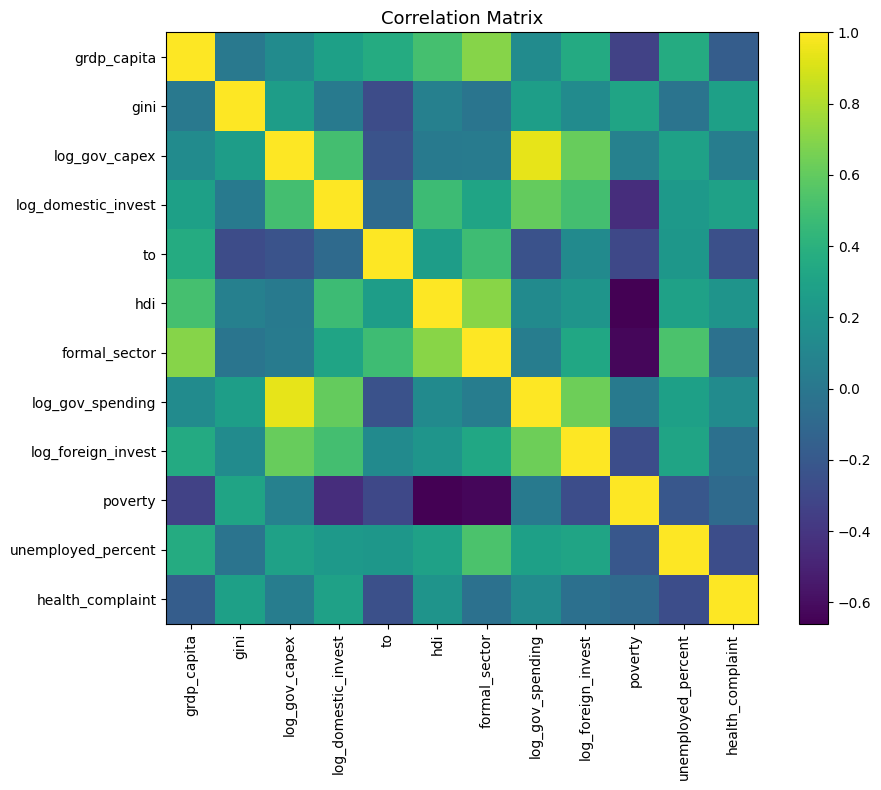

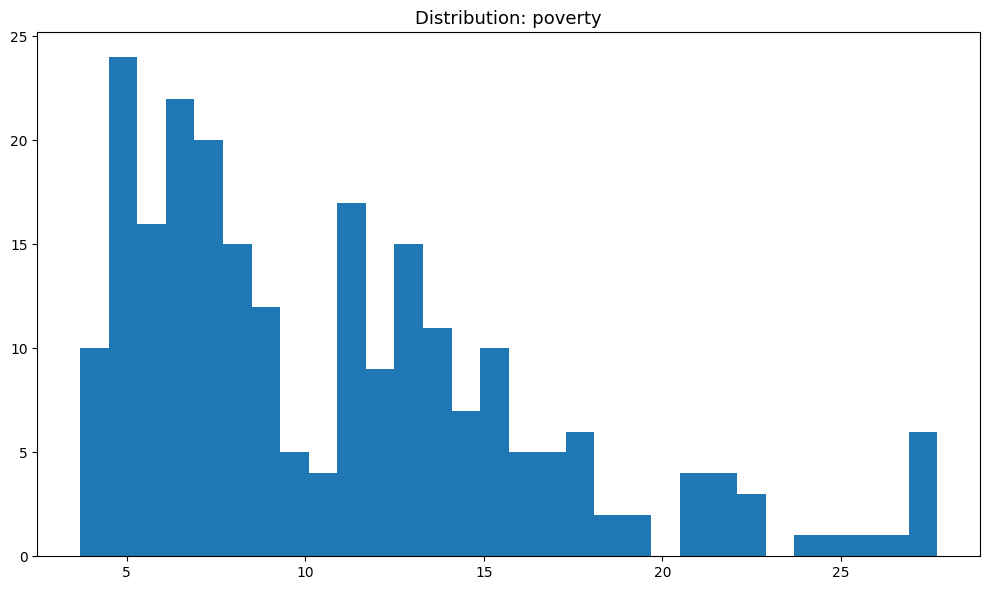

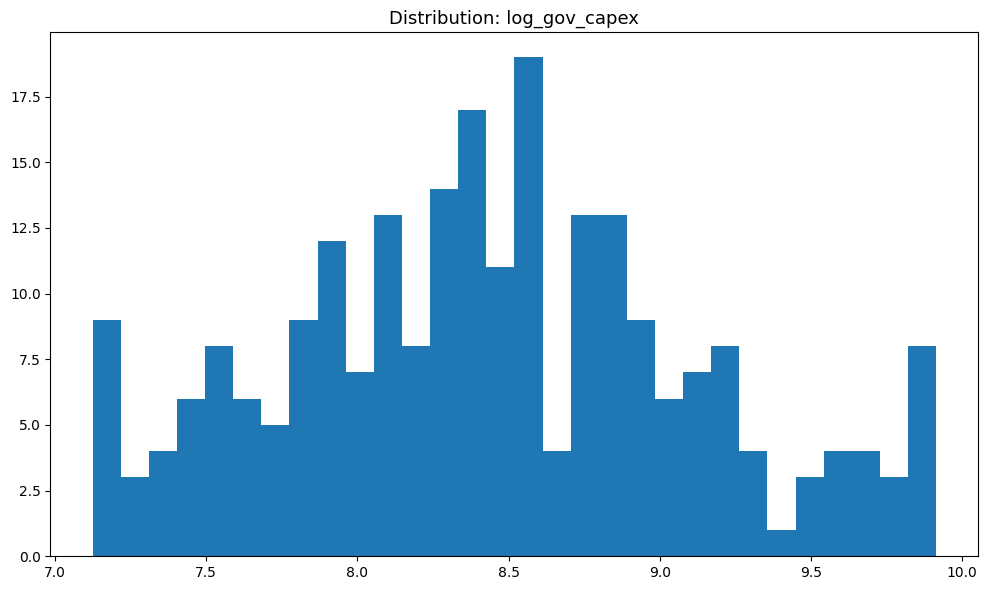


PART 1 COMPLETE


In [2]:
# =============================================================================
# HYBRID ECONOMETRIC + MACHINE LEARNING PIPELINE
# INCLUSIVE GROWTH IN INDONESIA
# PART 1 — FOUNDATION
# =============================================================================


# =============================================================================
# PROJECT CONFIGURATION
# =============================================================================

PROJECT_NAME = "Hybrid Econometric-Machine Learning Pipeline for Inclusive Growth in Indonesia"

OUTPUT_DIR = Path("results")
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"

OUTPUT_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(exist_ok=True)
TABLE_DIR.mkdir(exist_ok=True)

# =============================================================================
# DATASET SCHEMA
# =============================================================================

ENTITY_ID = "province"
TIME_ID = "year"

OUTCOME_VAR = "poverty"
RAW_TREATMENT_VAR = "gov_capex"

RAW_CONTROL_VARS = [
    "hdi",
    "gov_spending",
    "unemployed_percent",
    "domestic_invest",
    "foreign_invest",
    "to"
]

HETEROGENEITY_VARS = [
    "gini",
    "grdp_capita",
    "formal_sector",
    "health_complaint",
    "hdi",
    "unemployed_percent"
]

REQUIRED_RAW_COLUMNS = [
    ENTITY_ID,
    TIME_ID,
    OUTCOME_VAR,
    RAW_TREATMENT_VAR,
    *RAW_CONTROL_VARS,
    *HETEROGENEITY_VARS
]

REQUIRED_RAW_COLUMNS = list(set(REQUIRED_RAW_COLUMNS))

# =============================================================================
# GLOBAL MODEL VARIABLES
# =============================================================================

TREATMENT_VAR = "log_gov_capex"

CONTROL_VARS = [
    "hdi",
    "log_gov_spending",
    "unemployed_percent",
    "log_domestic_invest",
    "log_foreign_invest",
    "to"
]

MODEL_VARS = [
    OUTCOME_VAR,
    TREATMENT_VAR,
    *CONTROL_VARS,
    *HETEROGENEITY_VARS
]

MODEL_VARS = list(set(MODEL_VARS))

# =============================================================================
# DISPLAY CONFIG
# =============================================================================

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

print("=" * 90)
print(PROJECT_NAME)
print("=" * 90)

# =============================================================================
# HELPER FUNCTIONS
# =============================================================================

def validate_numeric_columns(df: pd.DataFrame, columns: List[str]) -> pd.DataFrame:
    """
    Force numeric conversion.
    """
    for col in columns:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df


def winsorize_series(series: pd.Series,
                     lower: float = 0.01,
                     upper: float = 0.01) -> pd.Series:
    """
    Winsorize extreme values.
    """
    return pd.Series(
        winsorize(series, limits=[lower, upper]),
        index=series.index
    )

# =============================================================================
# DATA LOADING
# =============================================================================

def load_panel_data(file_path: str,
                    sheet_name: Optional[str] = None) -> pd.DataFrame:
    """
    Load dataset safely.
    """

    print("\n[DATA LOADING]")

    file_ext = Path(file_path).suffix.lower()

    if file_ext == ".csv":
        df = pd.read_csv(file_path)

    elif file_ext in [".xlsx", ".xls"]:
        if sheet_name is None:
            df = pd.read_excel(file_path)
        else:
            df = pd.read_excel(file_path, sheet_name=sheet_name)

    elif file_ext == ".parquet":
        df = pd.read_parquet(file_path)

    else:
        raise ValueError(f"Unsupported format: {file_ext}")

    print(f"Loaded dataset shape: {df.shape}")

    return df

# =============================================================================
# VALIDATION
# =============================================================================

def validate_required_columns(df: pd.DataFrame) -> None:
    """
    Validate raw schema.
    """

    missing = [
        col for col in REQUIRED_RAW_COLUMNS
        if col not in df.columns
    ]

    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    print("[VALIDATION] Required columns OK.")


def check_duplicate_panel_keys(df: pd.DataFrame) -> None:
    """
    Detect duplicate province-year rows.
    """

    duplicates = df.duplicated(
        subset=[ENTITY_ID, TIME_ID]
    ).sum()

    if duplicates > 0:
        raise ValueError(
            f"Duplicate panel keys detected: {duplicates}"
        )

    print("[VALIDATION] No duplicate panel keys.")


def check_missingness(df: pd.DataFrame) -> pd.DataFrame:
    """
    Missing data report.
    """

    missing = df.isnull().sum()
    missing_pct = (missing / len(df)) * 100

    report = pd.DataFrame({
        "missing_count": missing,
        "missing_percent": missing_pct
    }).sort_values("missing_percent", ascending=False)

    report.to_csv(TABLE_DIR / "missingness_report.csv")

    print("\n[MISSINGNESS]")
    print(report)

    return report


def validate_panel_structure(df: pd.DataFrame) -> None:
    """
    Validate panel balance.
    """

    n_entities = df[ENTITY_ID].nunique()
    n_periods = df[TIME_ID].nunique()

    obs = df.groupby(ENTITY_ID).size()
    balanced = obs.nunique() == 1

    print("\n[PANEL STRUCTURE]")
    print(f"Entities       : {n_entities}")
    print(f"Time periods   : {n_periods}")
    print(f"Balanced panel : {balanced}")

# =============================================================================
# PREPROCESSING
# =============================================================================

def preprocess_panel_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Full preprocessing pipeline.
    """

    print("\n[PREPROCESSING]")

    df = df.copy()

    numeric_cols = REQUIRED_RAW_COLUMNS.copy()
    numeric_cols.remove(ENTITY_ID)
    numeric_cols.remove(TIME_ID)

    df = validate_numeric_columns(df, numeric_cols)

    # -------------------------------------------------------------------------
    # Log transforms
    # -------------------------------------------------------------------------
    skewed_vars = [
        "gov_capex",
        "gov_spending",
        "domestic_invest",
        "foreign_invest",
        "grdp_capita"
    ]

    for col in skewed_vars:
        if col in df.columns:
            df[f"log_{col}"] = np.log1p(df[col])

    # -------------------------------------------------------------------------
    # Imputation
    # -------------------------------------------------------------------------
    imputer = SimpleImputer(strategy="median")
    df[MODEL_VARS] = imputer.fit_transform(df[MODEL_VARS])

    # -------------------------------------------------------------------------
    # Winsorization
    # -------------------------------------------------------------------------
    for col in MODEL_VARS:
        df[col] = winsorize_series(df[col])

    # -------------------------------------------------------------------------
    # Sort + panel index
    # -------------------------------------------------------------------------
    df = df.sort_values([ENTITY_ID, TIME_ID])
    df = df.set_index([ENTITY_ID, TIME_ID])

    print("[PREPROCESSING] Complete.")

    return df

# =============================================================================
# DESCRIPTIVE ANALYTICS
# =============================================================================

def descriptive_statistics(df: pd.DataFrame) -> pd.DataFrame:
    """
    Descriptive stats.
    """

    desc = df[MODEL_VARS].describe().T

    desc["median"] = df[MODEL_VARS].median()
    desc["skewness"] = df[MODEL_VARS].skew()
    desc["kurtosis"] = df[MODEL_VARS].kurtosis()

    desc.to_csv(TABLE_DIR / "descriptive_statistics.csv")

    print("\n[DESCRIPTIVE STATISTICS]")
    print(desc)

    return desc


def province_summary(df: pd.DataFrame) -> pd.DataFrame:
    """
    Province averages.
    """

    summary = df.groupby(level=0)[
        [OUTCOME_VAR, TREATMENT_VAR]
    ].mean()

    summary.to_csv(TABLE_DIR / "province_summary.csv")

    return summary


def time_summary(df: pd.DataFrame) -> pd.DataFrame:
    """
    Year averages.
    """

    summary = df.groupby(level=1)[
        [OUTCOME_VAR, TREATMENT_VAR]
    ].mean()

    summary.to_csv(TABLE_DIR / "time_summary.csv")

    return summary

# =============================================================================
# VISUALIZATION
# =============================================================================

def plot_correlation_matrix(df: pd.DataFrame):
    """
    Correlation matrix.
    """

    corr = df[MODEL_VARS].corr()

    plt.figure(figsize=(10, 8))
    plt.imshow(corr)
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.colorbar()
    plt.title("Correlation Matrix")

    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "correlation_matrix.png", dpi=300)
    plt.show()


def plot_distributions(df: pd.DataFrame):
    """
    Key distributions.
    """

    vars_to_plot = [OUTCOME_VAR, TREATMENT_VAR]

    for var in vars_to_plot:
        plt.figure()
        plt.hist(df[var], bins=30)
        plt.title(f"Distribution: {var}")
        plt.tight_layout()
        plt.savefig(FIGURE_DIR / f"distribution_{var}.png", dpi=300)
        plt.show()

# =============================================================================
# PART 1 PIPELINE
# =============================================================================

def run_part1_pipeline(file_path: str,
                       sheet_name: Optional[str] = None) -> pd.DataFrame:
    """
    Execute Part 1.
    """

    df_raw = load_panel_data(file_path, sheet_name)

    validate_required_columns(df_raw)
    check_duplicate_panel_keys(df_raw)
    check_missingness(df_raw)
    validate_panel_structure(df_raw)

    df = preprocess_panel_data(df_raw)

    descriptive_statistics(df)
    province_summary(df)
    time_summary(df)

    plot_correlation_matrix(df)
    plot_distributions(df)

    print("\n" + "=" * 90)
    print("PART 1 COMPLETE")
    print("=" * 90)

    return df

# =============================================================================
# TEST RUN
# =============================================================================

df = run_part1_pipeline(
    file_path="clean_dat_inclusive growth determinants.xlsx"
)



[VIF RESULTS]
              variable       vif
1                  hdi  1.561866
2     log_gov_spending  2.543836
3   unemployed_percent  1.249833
4  log_domestic_invest  2.215550
5   log_foreign_invest  2.022441
6                   to  1.419834

[BREUSCH-PAGAN TEST]
{'LM Statistic': np.float64(47.30111808272219), 'LM p-value': np.float64(4.8757242317353065e-08), 'F Statistic': np.float64(8.14991455912555), 'F p-value': np.float64(7.311004724974725e-09)}

[OUTLIER DIAGNOSTICS]
              variable  outliers
0              poverty         8
1        log_gov_capex         0
2                  hdi        24
3     log_gov_spending         0
4   unemployed_percent         0
5  log_domestic_invest         8
6   log_foreign_invest         0
7                   to        12

[TWFE RESULTS]
                          PanelOLS Estimation Summary                           
Dep. Variable:                poverty   R-squared:                        0.2509
Estimator:                   PanelOLS   R-s

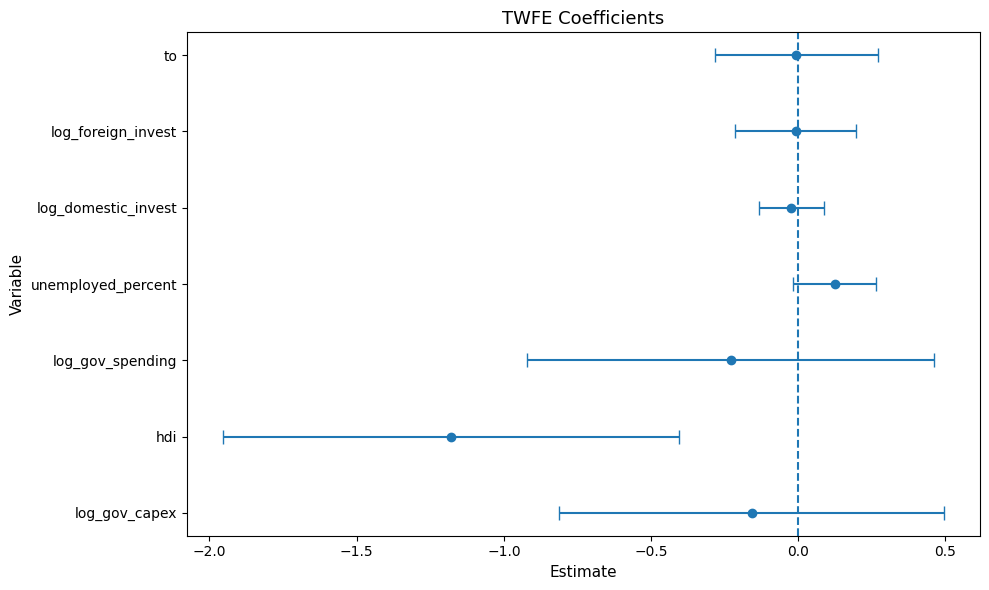


[PANEL DML RESULTS]
ATE: -0.2541
95% CI: (-0.7259, 0.2178)

PART 2 COMPLETE


In [3]:
# =============================================================================
# PART 2 — ECONOMETRIC CORE
# =============================================================================

# ECONOMETRIC DIAGNOSTICS

def calculate_vif(df: pd.DataFrame) -> pd.DataFrame:
    """
    Variance Inflation Factor diagnostics.
    """

    X = sm.add_constant(df[CONTROL_VARS])

    vif = pd.DataFrame({
        "variable": X.columns,
        "vif": [
            variance_inflation_factor(X.values, i)
            for i in range(X.shape[1])
        ]
    })

    vif = vif[vif["variable"] != "const"]

    vif.to_csv(TABLE_DIR / "vif_results.csv", index=False)

    print("\n[VIF RESULTS]")
    print(vif)

    return vif


def breusch_pagan_test(df: pd.DataFrame) -> dict:
    """
    Heteroskedasticity diagnostic.
    """

    y = df[OUTCOME_VAR]
    X = sm.add_constant(df[[TREATMENT_VAR] + CONTROL_VARS])

    ols = sm.OLS(y, X).fit()

    bp = het_breuschpagan(
        ols.resid,
        ols.model.exog
    )

    results = {
        "LM Statistic": bp[0],
        "LM p-value": bp[1],
        "F Statistic": bp[2],
        "F p-value": bp[3]
    }

    print("\n[BREUSCH-PAGAN TEST]")
    print(results)

    return results


def outlier_diagnostics(df: pd.DataFrame) -> pd.DataFrame:
    """
    Extreme-value diagnostics.
    """

    diagnostics = []

    vars_to_check = [OUTCOME_VAR, TREATMENT_VAR] + CONTROL_VARS

    for var in vars_to_check:
        q1 = df[var].quantile(0.25)
        q3 = df[var].quantile(0.75)
        iqr = q3 - q1

        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        outliers = ((df[var] < lower) | (df[var] > upper)).sum()

        diagnostics.append({
            "variable": var,
            "outliers": outliers
        })

    diag = pd.DataFrame(diagnostics)

    diag.to_csv(TABLE_DIR / "outlier_diagnostics.csv", index=False)

    print("\n[OUTLIER DIAGNOSTICS]")
    print(diag)

    return diag

# =============================================================================
# TWFE
# =============================================================================

def run_twfe(df: pd.DataFrame):
    """
    Two-way fixed effects model.
    """

    y = df[OUTCOME_VAR]

    X = df[
        [TREATMENT_VAR] + CONTROL_VARS
    ]

    model = PanelOLS(
        dependent=y,
        exog=X,
        entity_effects=True,
        time_effects=True
    )

    results = model.fit(
        cov_type="clustered",
        cluster_entity=True
    )

    coef_table = pd.DataFrame({
        "coefficient": results.params,
        "std_error": results.std_errors,
        "t_stat": results.tstats,
        "p_value": results.pvalues
    })

    coef_table.to_csv(
        TABLE_DIR / "twfe_results.csv"
    )

    print("\n[TWFE RESULTS]")
    print(results.summary)

    return results


def plot_twfe_coefficients(results):
    """
    TWFE coefficient plot.
    """

    coef = results.params
    se = results.std_errors

    plt.figure(figsize=(10, 6))

    plt.errorbar(
        coef.values,
        coef.index,
        xerr=1.96 * se.values,
        fmt='o',
        capsize=5
    )

    plt.axvline(0, linestyle='--')

    plt.title("TWFE Coefficients")
    plt.xlabel("Estimate")
    plt.ylabel("Variable")

    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "twfe_coefficients.png", dpi=300)
    plt.show()

# =============================================================================
# PANEL DML
# =============================================================================

def residualize_fixed_effects(df: pd.DataFrame,
                              variable: str) -> pd.Series:
    """
    Residualize variable against province + year fixed effects.
    """

    y = pd.to_numeric(
        df[variable],
        errors="coerce"
    ).astype(float)

    entity = pd.get_dummies(
        df.index.get_level_values(0),
        drop_first=True,
        dtype=float
    )

    time = pd.get_dummies(
        df.index.get_level_values(1),
        drop_first=True,
        dtype=float
    )

    # CRITICAL FIX: align indices
    entity.index = df.index
    time.index = df.index

    X = pd.concat(
        [entity, time],
        axis=1
    )

    X = sm.add_constant(X)
    X = X.astype(float)

    model = sm.OLS(y, X).fit()

    return model.resid


def prepare_dml_inputs(df: pd.DataFrame):
    """
    Prepare panel-aware DML inputs.
    """

    Y = residualize_fixed_effects(
        df,
        OUTCOME_VAR
    )

    T = residualize_fixed_effects(
        df,
        TREATMENT_VAR
    )

    X = df[HETEROGENEITY_VARS].copy()

    scaler = StandardScaler()

    X_scaled = scaler.fit_transform(X)

    return Y.values, T.values, X_scaled


def run_panel_dml(df: pd.DataFrame):
    """
    Panel-aware Double Machine Learning.
    """

    Y, T, X = prepare_dml_inputs(df)

    cv = KFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    dml = LinearDML(
        model_y=RandomForestRegressor(
            n_estimators=300,
            max_depth=8,
            random_state=42,
            n_jobs=-1
        ),
        model_t=RandomForestRegressor(
            n_estimators=300,
            max_depth=8,
            random_state=42,
            n_jobs=-1
        ),
        cv=cv,
        discrete_treatment=False,
        random_state=42
    )

    dml.fit(
        Y=Y,
        T=T,
        X=X
    )

    ate = dml.ate(X)
    ci = dml.ate_interval(X)

    results = pd.DataFrame({
        "metric": ["ATE", "CI Lower", "CI Upper"],
        "value": [ate, ci[0], ci[1]]
    })

    results.to_csv(
        TABLE_DIR / "panel_dml_results.csv",
        index=False
    )

    print("\n[PANEL DML RESULTS]")
    print(f"ATE: {ate:.4f}")
    print(f"95% CI: ({ci[0]:.4f}, {ci[1]:.4f})")

    return dml

# =============================================================================
# PART 2 PIPELINE
# =============================================================================

def run_part2_pipeline(df: pd.DataFrame):
    """
    Execute Part 2.
    """

    calculate_vif(df)
    breusch_pagan_test(df)
    outlier_diagnostics(df)

    twfe_results = run_twfe(df)

    plot_twfe_coefficients(
        twfe_results
    )

    dml_model = run_panel_dml(df)

    print("\n" + "=" * 90)
    print("PART 2 COMPLETE")
    print("=" * 90)

    return {
        "twfe": twfe_results,
        "dml": dml_model
    }

part2 = run_part2_pipeline(df)


[CAUSAL FOREST]
Mean CATE: -0.3376
Std  CATE: 0.3160


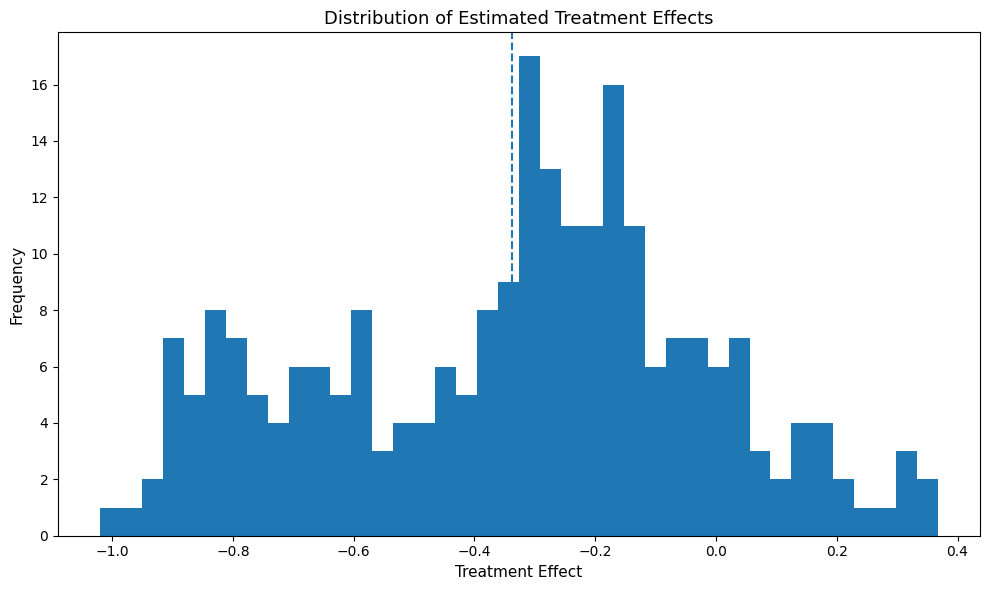


[PROVINCE HETEROGENEITY]
                          mean       std  count        se  ci_lower  ci_upper
province                                                                     
GORONTALO            -0.908825  0.074369      7  0.028109 -0.963919 -0.853732
DI YOGYAKARTA        -0.804509  0.147588      7  0.055783 -0.913844 -0.695174
KALIMANTAN SELATAN   -0.771584  0.087296      7  0.032995 -0.836254 -0.706915
KEP. BANGKA BELITUNG -0.740304  0.113476      7  0.042890 -0.824368 -0.656240
NUSA TENGGARA BARAT  -0.740071  0.161055      7  0.060873 -0.859382 -0.620760
JAWA TENGAH          -0.704680  0.242295      7  0.091579 -0.884175 -0.525185
KALIMANTAN UTARA     -0.620895  0.057723      7  0.021817 -0.663657 -0.578133
NUSA TENGGARA TIMUR  -0.619010  0.205757      7  0.077769 -0.771437 -0.466582
JAWA TIMUR           -0.590839  0.274649      7  0.103808 -0.794302 -0.387376
BALI                 -0.433338  0.277853      7  0.105019 -0.639174 -0.227502


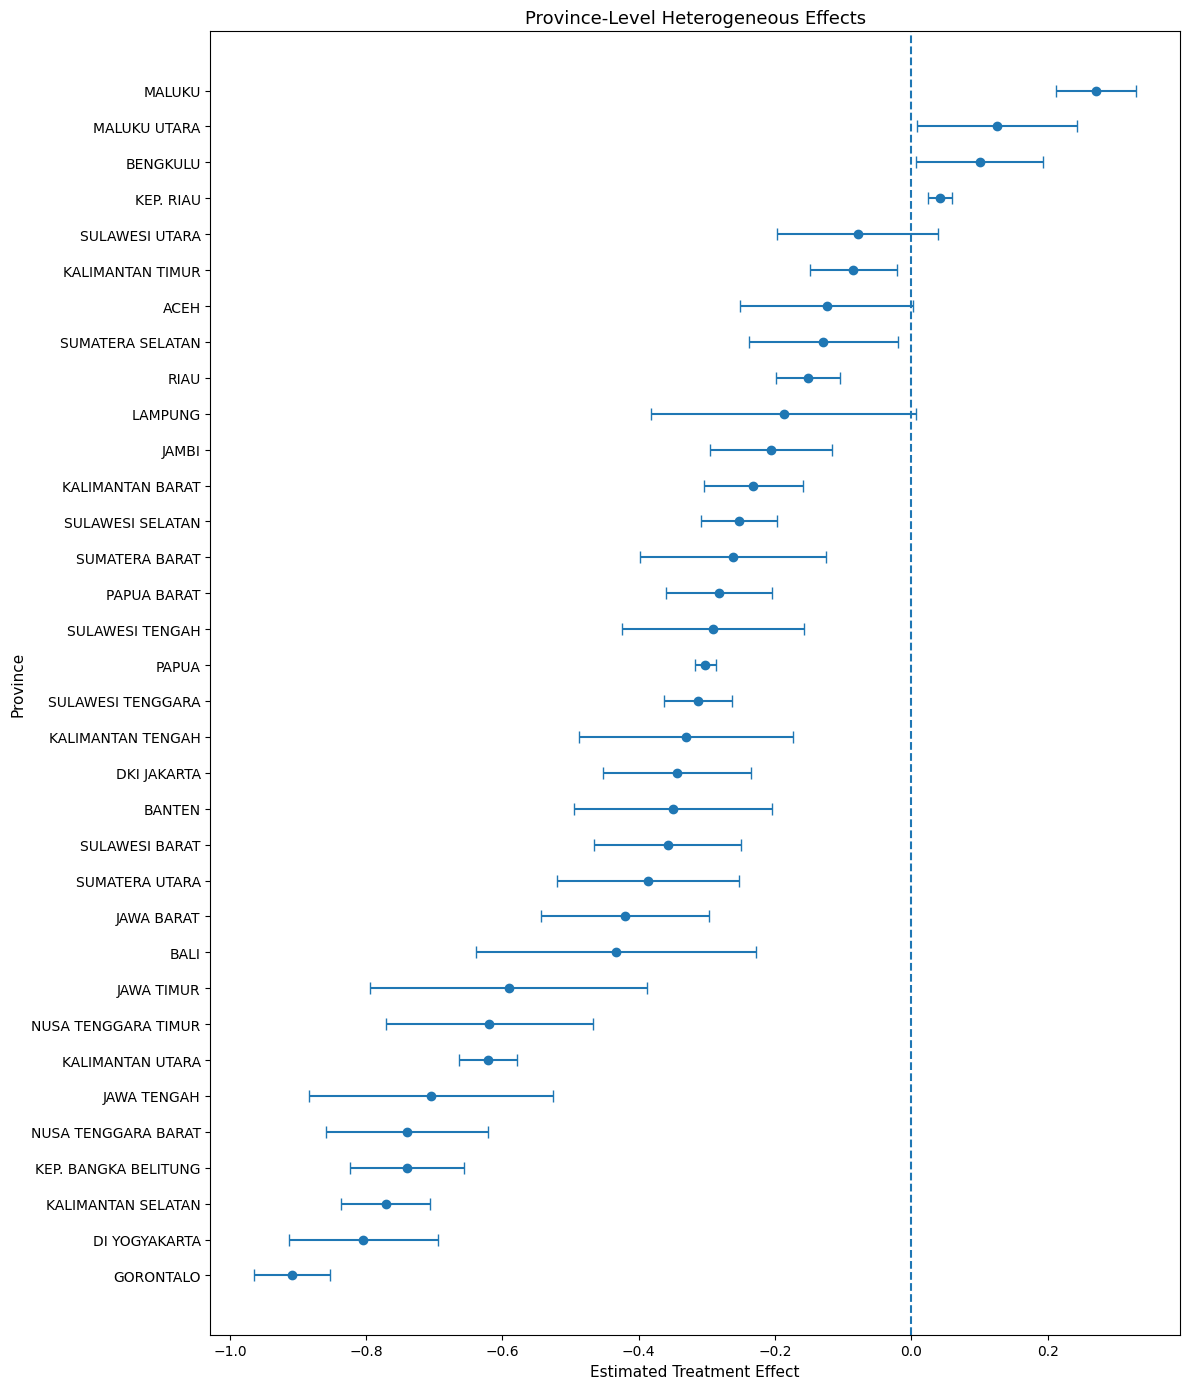

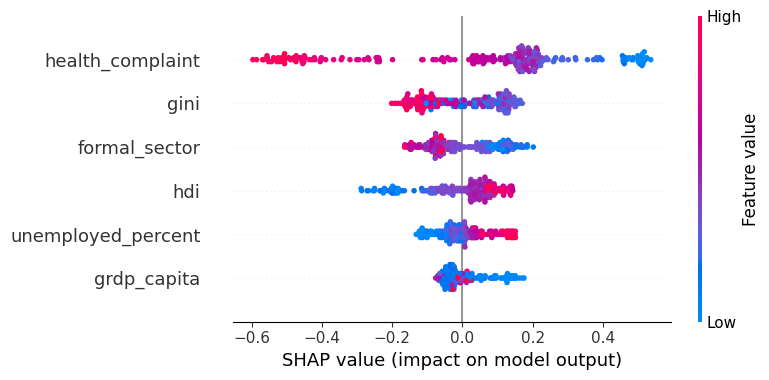


[SHAP COMPLETE]

[LASSO ROBUSTNESS] ATE: -0.4038
[PLACEBO TEST] ATE: 0.0322

PART 3 COMPLETE


In [4]:
# =============================================================================
# PART 3 — HETEROGENEOUS CAUSAL INFERENCE
# =============================================================================

from econml.dml import CausalForestDML
from sklearn.linear_model import LassoCV
import shap

# =============================================================================
# CAUSAL FOREST
# =============================================================================

def run_causal_forest(df: pd.DataFrame):
    """
    Estimate heterogeneous treatment effects.
    """

    Y, T, X = prepare_dml_inputs(df)

    cf = CausalForestDML(
        model_y=RandomForestRegressor(
            n_estimators=300,
            max_depth=8,
            random_state=42,
            n_jobs=-1
        ),
        model_t=RandomForestRegressor(
            n_estimators=300,
            max_depth=8,
            random_state=42,
            n_jobs=-1
        ),
        n_estimators=1000,
        min_samples_leaf=5,
        max_depth=12,
        discrete_treatment=False,
        random_state=42
    )

    cf.fit(
        Y=Y,
        T=T,
        X=X
    )

    cate = cf.effect(X)

    cate_df = df.copy()
    cate_df["estimated_treatment_effect"] = cate

    cate_df.to_csv(
        TABLE_DIR / "cate_observation_level.csv"
    )

    print("\n[CAUSAL FOREST]")
    print(f"Mean CATE: {np.mean(cate):.4f}")
    print(f"Std  CATE: {np.std(cate):.4f}")

    return cf, cate_df


# =============================================================================
# CATE DISTRIBUTION
# =============================================================================

def plot_cate_distribution(cate_df: pd.DataFrame):
    """
    Treatment effect distribution.
    """

    plt.figure(figsize=(10, 6))

    plt.hist(
        cate_df["estimated_treatment_effect"],
        bins=40
    )

    plt.axvline(
        cate_df["estimated_treatment_effect"].mean(),
        linestyle='--'
    )

    plt.title("Distribution of Estimated Treatment Effects")
    plt.xlabel("Treatment Effect")
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.savefig(
        FIGURE_DIR / "cate_distribution.png",
        dpi=300
    )
    plt.show()


# =============================================================================
# PROVINCE HETEROGENEITY
# =============================================================================

def province_heterogeneity(cate_df: pd.DataFrame):
    """
    Province-level heterogeneous treatment effects.
    """

    province = (
        cate_df
        .groupby(level=0)["estimated_treatment_effect"]
        .agg(["mean", "std", "count"])
    )

    province["se"] = (
        province["std"] /
        np.sqrt(province["count"])
    )

    province["ci_lower"] = (
        province["mean"] -
        1.96 * province["se"]
    )

    province["ci_upper"] = (
        province["mean"] +
        1.96 * province["se"]
    )

    province = province.sort_values("mean")

    province.to_csv(
        TABLE_DIR / "province_heterogeneity.csv"
    )

    print("\n[PROVINCE HETEROGENEITY]")
    print(province.head(10))

    return province


def plot_province_forest(province: pd.DataFrame):
    """
    Forest plot.
    """

    plt.figure(figsize=(12, 14))

    plt.errorbar(
        province["mean"],
        province.index,
        xerr=1.96 * province["se"],
        fmt='o',
        capsize=4
    )

    plt.axvline(0, linestyle='--')

    plt.title("Province-Level Heterogeneous Effects")
    plt.xlabel("Estimated Treatment Effect")
    plt.ylabel("Province")

    plt.tight_layout()
    plt.savefig(
        FIGURE_DIR / "province_forest_plot.png",
        dpi=300
    )
    plt.show()


# =============================================================================
# SHAP INTERPRETABILITY
# =============================================================================

def run_shap(cf_model, df: pd.DataFrame):
    """
    SHAP interpretability for causal forest heterogeneity.
    """

    _, _, X = prepare_dml_inputs(df)

    try:
        shap_values = cf_model.shap_values(X)

        # econml structure:
        # {'Y0': {'T0_1': shap_matrix}}

        y_key = list(shap_values.keys())[0]
        inner = shap_values[y_key]

        if isinstance(inner, dict):
            t_key = list(inner.keys())[0]
            shap_matrix = inner[t_key]
        else:
            shap_matrix = inner

        shap.summary_plot(
            shap_matrix,
            X,
            feature_names=HETEROGENEITY_VARS,
            show=False
        )

        plt.tight_layout()
        plt.savefig(
            FIGURE_DIR / "shap_summary.png",
            dpi=300
        )
        plt.show()

        print("\n[SHAP COMPLETE]")

    except Exception as e:
        print(f"SHAP warning: {e}")


# =============================================================================
# ROBUSTNESS
# =============================================================================

def robustness_lasso(df: pd.DataFrame):
    """
    Alternative learner robustness.
    """

    Y, T, X = prepare_dml_inputs(df)

    robust = LinearDML(
        model_y=LassoCV(cv=5),
        model_t=LassoCV(cv=5),
        discrete_treatment=False,
        random_state=42
    )

    robust.fit(
        Y=Y,
        T=T,
        X=X
    )

    ate = robust.ate(X)

    print(f"\n[LASSO ROBUSTNESS] ATE: {ate:.4f}")

    return ate


def placebo_test(df: pd.DataFrame):
    """
    Placebo test.
    """

    placebo_df = df.copy()

    placebo_df[TREATMENT_VAR] = np.random.permutation(
        placebo_df[TREATMENT_VAR].values
    )

    Y, T, X = prepare_dml_inputs(placebo_df)

    placebo = LinearDML(
        model_y=RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ),
        model_t=RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ),
        discrete_treatment=False,
        random_state=42
    )

    placebo.fit(
        Y=Y,
        T=T,
        X=X
    )

    ate = placebo.ate(X)

    print(f"[PLACEBO TEST] ATE: {ate:.4f}")

    return ate


# =============================================================================
# PART 3 PIPELINE
# =============================================================================

def run_part3_pipeline(df: pd.DataFrame):
    """
    Execute Part 3.
    """

    cf_model, cate_df = run_causal_forest(df)

    plot_cate_distribution(cate_df)

    province = province_heterogeneity(cate_df)

    plot_province_forest(province)

    run_shap(cf_model, df)

    robustness_lasso(df)

    placebo_test(df)

    print("\n" + "=" * 90)
    print("PART 3 COMPLETE")
    print("=" * 90)

    return {
        "causal_forest": cf_model,
        "cate_data": cate_df,
        "province": province
    }

part3 = run_part3_pipeline(df)


FULL RESEARCH PIPELINE START

[DATA LOADING]
Loaded dataset shape: (238, 24)
[VALIDATION] Required columns OK.
[VALIDATION] No duplicate panel keys.

[MISSINGNESS]
                     missing_count  missing_percent
domestic_invest                  1         0.420168
province                         0         0.000000
grdp_employed                    0         0.000000
year                             0         0.000000
health_complaint                 0         0.000000
to                               0         0.000000
formal_sector                    0         0.000000
grdp_capita                      0         0.000000
unemployed_percent               0         0.000000
hdi                              0         0.000000
gov_capex                        0         0.000000
gov_spending                     0         0.000000
poverty                          0         0.000000
gini                             0         0.000000
decent_sanitation                0         0.000000
reg

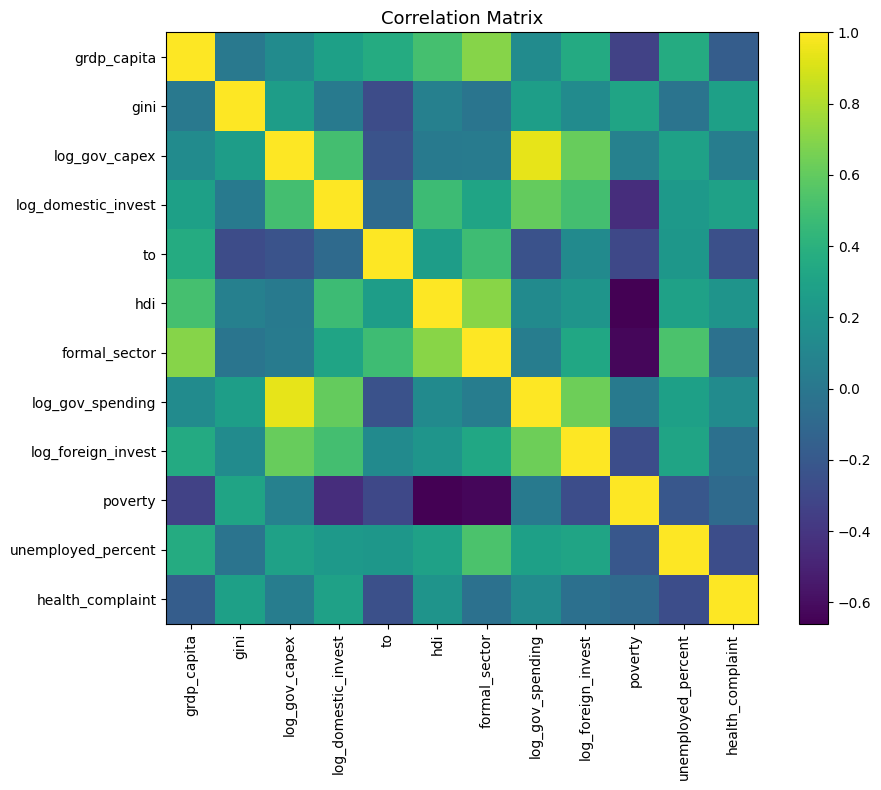

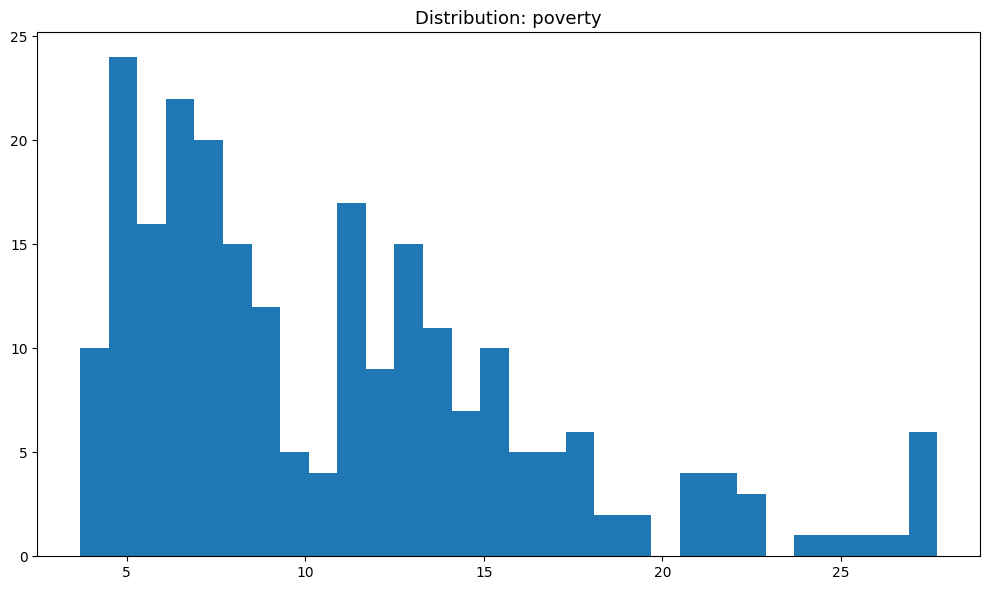

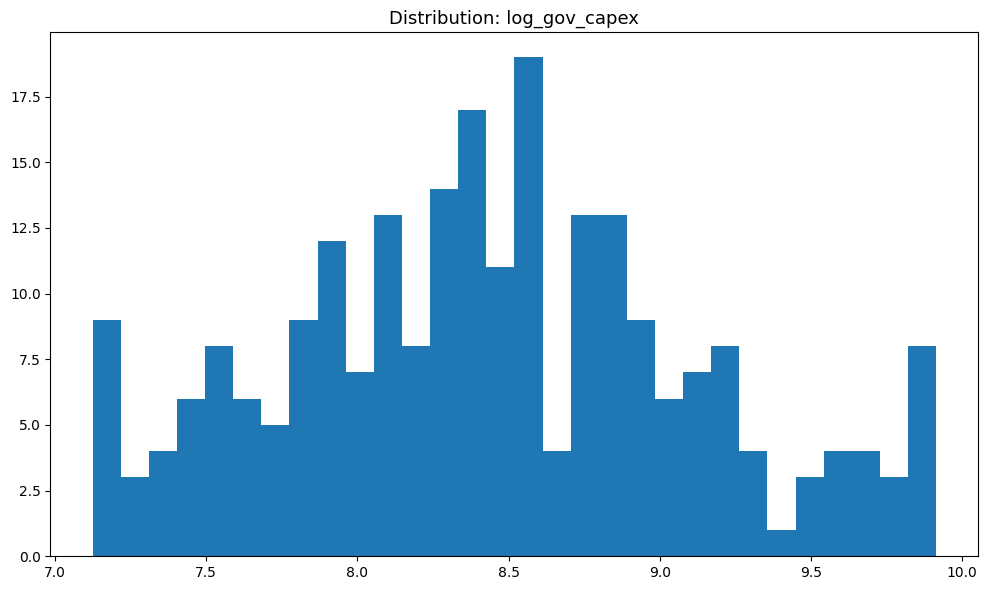


PART 1 COMPLETE

[VIF RESULTS]
              variable       vif
1                  hdi  1.561866
2     log_gov_spending  2.543836
3   unemployed_percent  1.249833
4  log_domestic_invest  2.215550
5   log_foreign_invest  2.022441
6                   to  1.419834

[BREUSCH-PAGAN TEST]
{'LM Statistic': np.float64(47.30111808272219), 'LM p-value': np.float64(4.8757242317353065e-08), 'F Statistic': np.float64(8.14991455912555), 'F p-value': np.float64(7.311004724974725e-09)}

[OUTLIER DIAGNOSTICS]
              variable  outliers
0              poverty         8
1        log_gov_capex         0
2                  hdi        24
3     log_gov_spending         0
4   unemployed_percent         0
5  log_domestic_invest         8
6   log_foreign_invest         0
7                   to        12

[TWFE RESULTS]
                          PanelOLS Estimation Summary                           
Dep. Variable:                poverty   R-squared:                        0.2509
Estimator:                

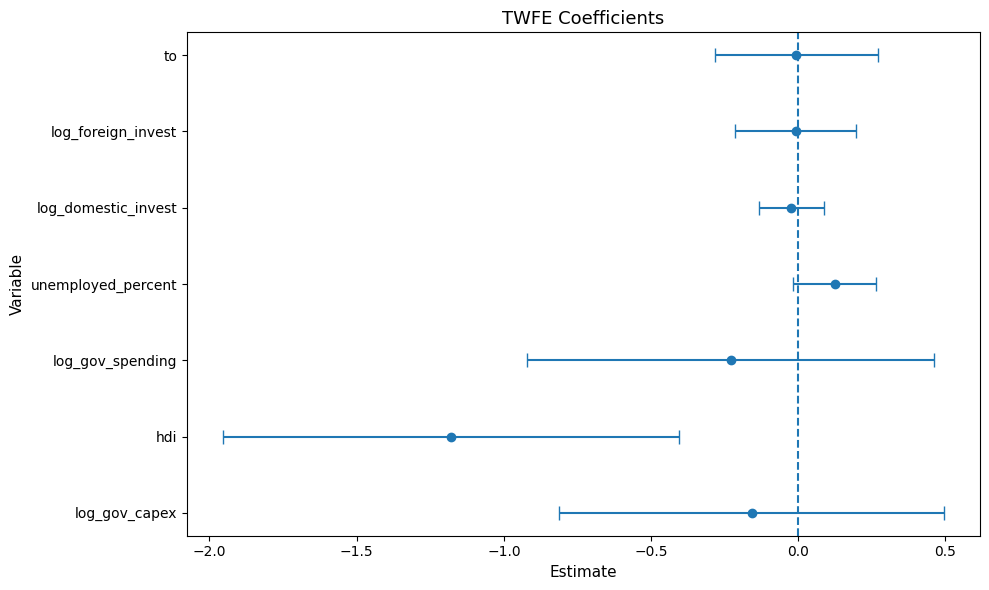


[PANEL DML RESULTS]
ATE: -0.2541
95% CI: (-0.7259, 0.2178)

PART 2 COMPLETE

[CAUSAL FOREST]
Mean CATE: -0.3374
Std  CATE: 0.3160


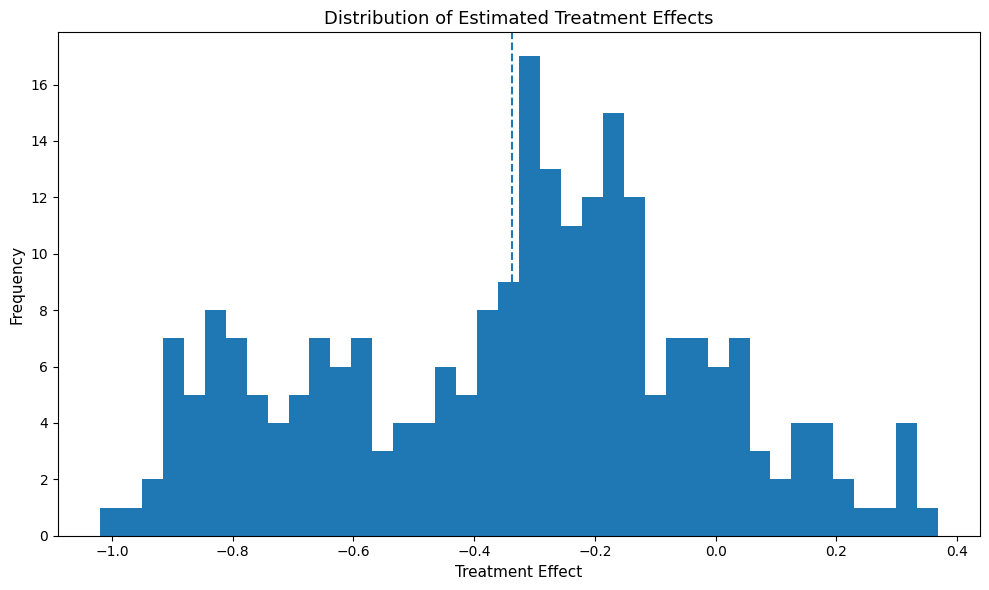


[PROVINCE HETEROGENEITY]
                          mean       std  count        se  ci_lower  ci_upper
province                                                                     
GORONTALO            -0.908740  0.073974      7  0.027960 -0.963541 -0.853939
DI YOGYAKARTA        -0.804663  0.147653      7  0.055808 -0.914046 -0.695280
KALIMANTAN SELATAN   -0.771578  0.087289      7  0.032992 -0.836243 -0.706914
KEP. BANGKA BELITUNG -0.740505  0.113376      7  0.042852 -0.824495 -0.656515
NUSA TENGGARA BARAT  -0.739805  0.161240      7  0.060943 -0.859254 -0.620357
JAWA TENGAH          -0.704812  0.241945      7  0.091447 -0.884047 -0.525577
KALIMANTAN UTARA     -0.620224  0.054313      7  0.020528 -0.660460 -0.579988
NUSA TENGGARA TIMUR  -0.618393  0.205829      7  0.077796 -0.770873 -0.465912
JAWA TIMUR           -0.591223  0.272827      7  0.103119 -0.793336 -0.389110
BALI                 -0.433779  0.277619      7  0.104930 -0.639442 -0.228116


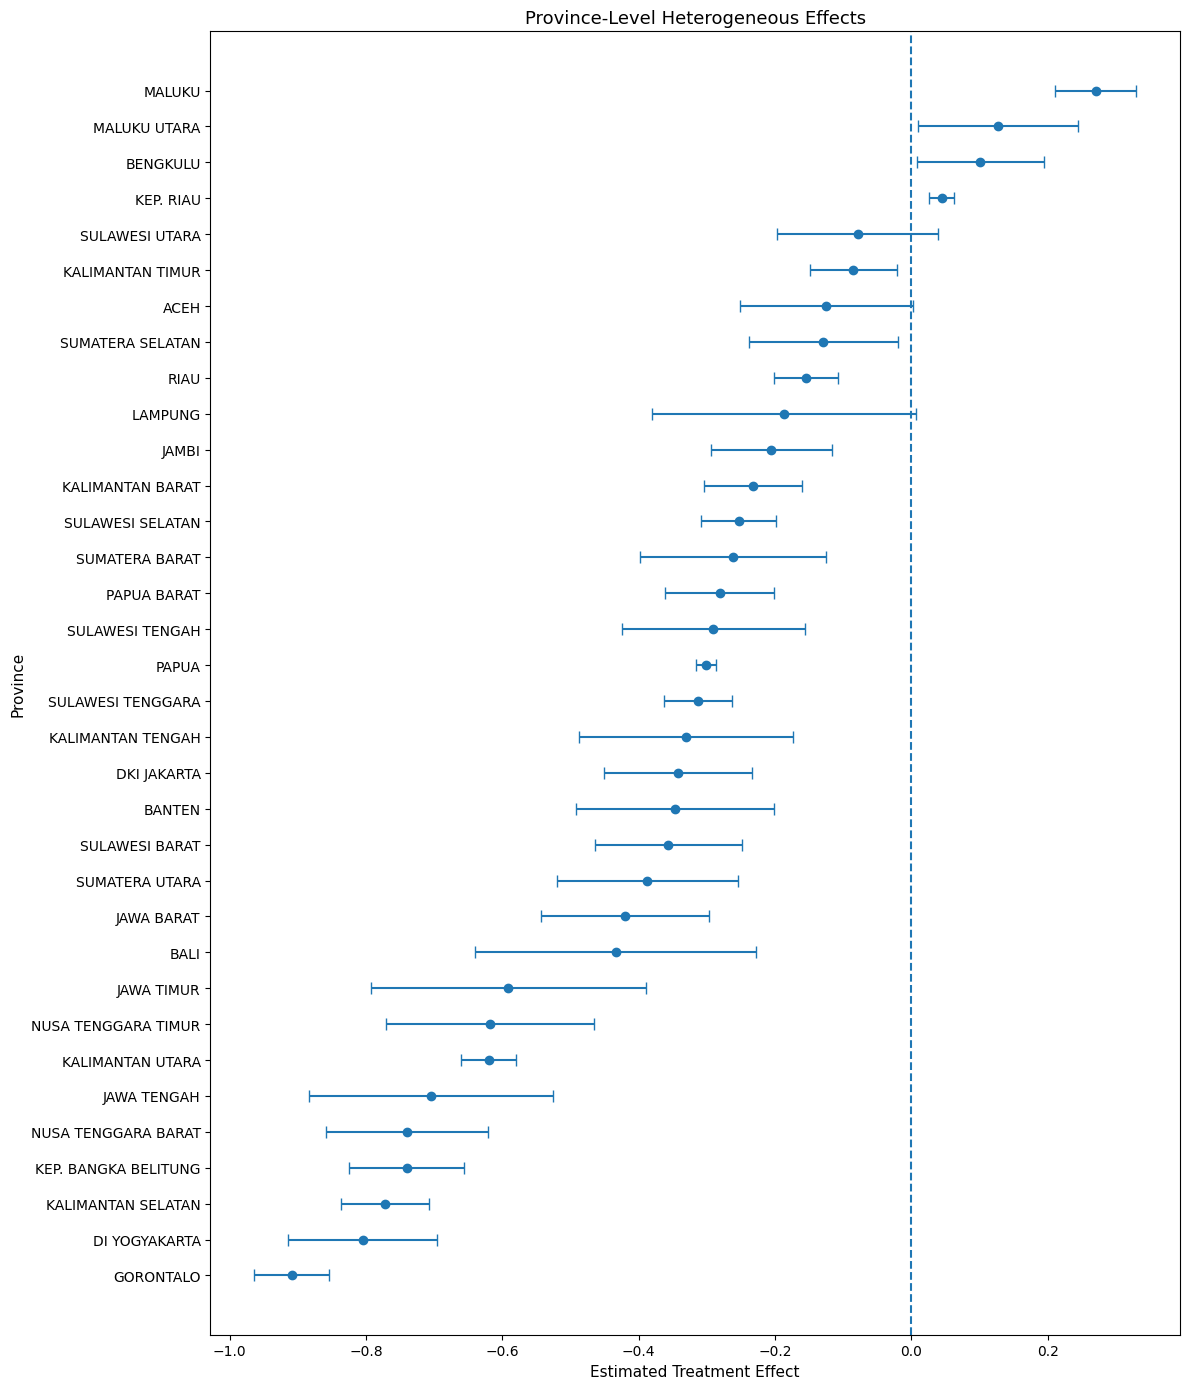

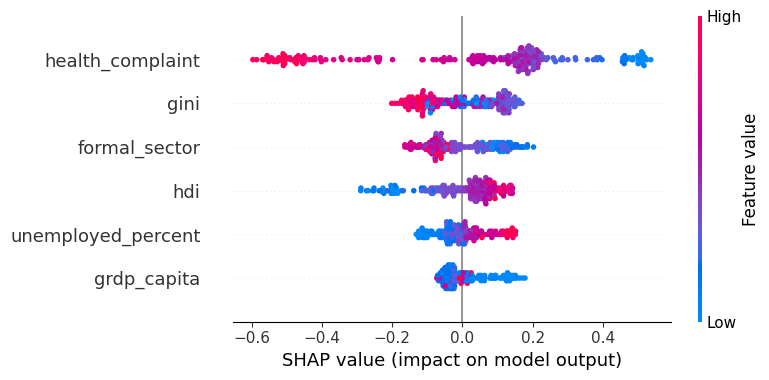


[SHAP COMPLETE]

[LASSO ROBUSTNESS] ATE: -0.4038
[PLACEBO TEST] ATE: -0.0157

PART 3 COMPLETE

[MODEL COMPARISON]
                           model  estimate  ci_lower  ci_upper
0          Two-Way Fixed Effects -0.158645 -0.812264  0.494974
1  Panel Double Machine Learning -0.254074 -0.725940  0.217793
[TWFE TABLE EXPORTED]
[DESCRIPTIVE TABLE EXPORTED]


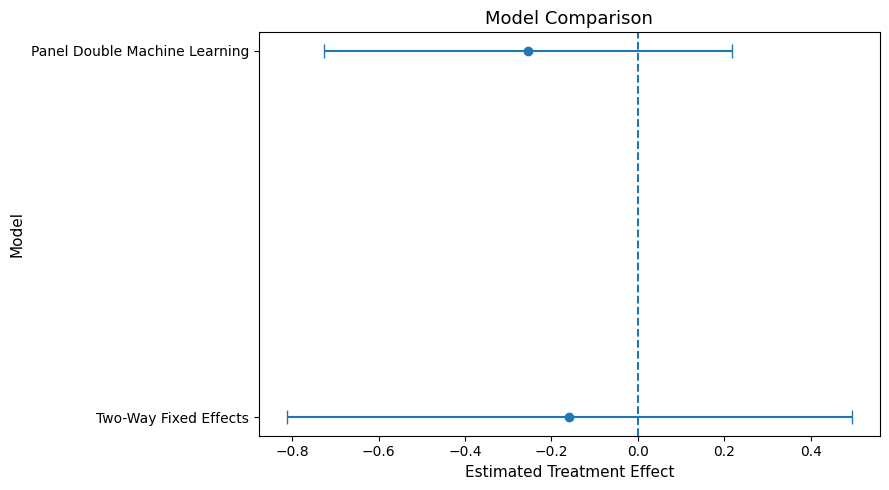

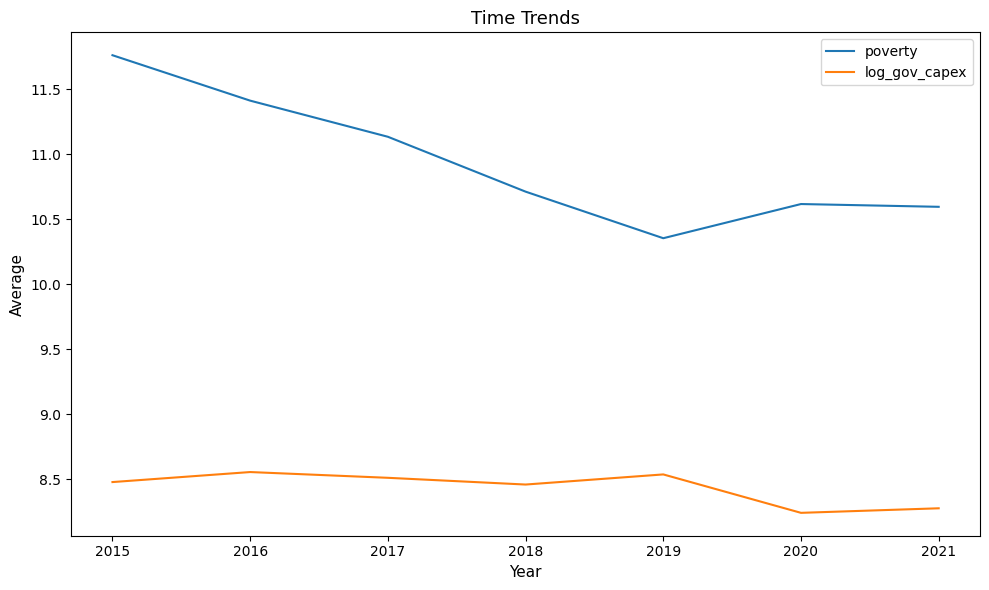


[EXPORTED FILES]
- missingness_report.csv
- descriptive_statistics.csv
- vif_results.csv
- outlier_diagnostics.csv
- twfe_results.csv
- panel_dml_results.csv
- cate_observation_level.csv
- province_heterogeneity.csv
- model_comparison.csv
- twfe_publication_table.xlsx
- descriptive_publication_table.xlsx

FULL RESEARCH PIPELINE COMPLETE


In [5]:
# =============================================================================
# PART 4 — REPORTING + PUBLICATION OUTPUTS
# =============================================================================

# =============================================================================
# MODEL COMPARISON TABLE
# =============================================================================

def build_model_comparison_table(part2_results, df: pd.DataFrame):
    """
    Compare TWFE vs DML.
    """

    twfe = part2_results["twfe"]
    dml = part2_results["dml"]

    _, _, X = prepare_dml_inputs(df)

    dml_ate = dml.ate(X)
    dml_ci = dml.ate_interval(X)

    comparison = pd.DataFrame({
        "model": [
            "Two-Way Fixed Effects",
            "Panel Double Machine Learning"
        ],
        "estimate": [
            twfe.params[TREATMENT_VAR],
            dml_ate
        ],
        "ci_lower": [
            twfe.params[TREATMENT_VAR] -
            1.96 * twfe.std_errors[TREATMENT_VAR],
            dml_ci[0]
        ],
        "ci_upper": [
            twfe.params[TREATMENT_VAR] +
            1.96 * twfe.std_errors[TREATMENT_VAR],
            dml_ci[1]
        ]
    })

    comparison.to_csv(
        TABLE_DIR / "model_comparison.csv",
        index=False
    )

    print("\n[MODEL COMPARISON]")
    print(comparison)

    return comparison


# =============================================================================
# TWFE PUBLICATION TABLE
# =============================================================================

def export_twfe_publication_table(part2_results):
    """
    Export TWFE regression table.
    """

    twfe = part2_results["twfe"]

    table = pd.DataFrame({
        "Variable": twfe.params.index,
        "Coefficient": twfe.params.values,
        "Std.Error": twfe.std_errors.values,
        "t-stat": twfe.tstats.values,
        "p-value": twfe.pvalues.values
    })

    table.to_excel(
        TABLE_DIR / "twfe_publication_table.xlsx",
        index=False
    )

    print("[TWFE TABLE EXPORTED]")

    return table


# =============================================================================
# DESCRIPTIVE PUBLICATION TABLE
# =============================================================================

def export_descriptive_publication_table(df: pd.DataFrame):
    """
    Export descriptive statistics.
    """

    desc = df[MODEL_VARS].describe().T

    desc["median"] = df[MODEL_VARS].median()
    desc["skewness"] = df[MODEL_VARS].skew()
    desc["kurtosis"] = df[MODEL_VARS].kurtosis()

    desc.to_excel(
        TABLE_DIR / "descriptive_publication_table.xlsx"
    )

    print("[DESCRIPTIVE TABLE EXPORTED]")

    return desc


# =============================================================================
# MODEL COMPARISON PLOT
# =============================================================================

def plot_model_comparison(comparison: pd.DataFrame):
    """
    Compare causal estimates.
    """

    plt.figure(figsize=(9, 5))

    lower = comparison["estimate"] - comparison["ci_lower"]
    upper = comparison["ci_upper"] - comparison["estimate"]

    plt.errorbar(
        comparison["estimate"],
        comparison["model"],
        xerr=[lower, upper],
        fmt='o',
        capsize=5
    )

    plt.axvline(0, linestyle='--')

    plt.title("Model Comparison")
    plt.xlabel("Estimated Treatment Effect")
    plt.ylabel("Model")

    plt.tight_layout()
    plt.savefig(
        FIGURE_DIR / "model_comparison.png",
        dpi=300
    )
    plt.show()


# =============================================================================
# TIME TRENDS
# =============================================================================

def plot_time_trends(df: pd.DataFrame):
    """
    Poverty + treatment trends.
    """

    trend = df.groupby(level=1)[
        [OUTCOME_VAR, TREATMENT_VAR]
    ].mean()

    plt.figure(figsize=(10, 6))

    plt.plot(
        trend.index,
        trend[OUTCOME_VAR],
        label=OUTCOME_VAR
    )

    plt.plot(
        trend.index,
        trend[TREATMENT_VAR],
        label=TREATMENT_VAR
    )

    plt.legend()

    plt.title("Time Trends")
    plt.xlabel("Year")
    plt.ylabel("Average")

    plt.tight_layout()
    plt.savefig(
        FIGURE_DIR / "time_trends.png",
        dpi=300
    )
    plt.show()


# =============================================================================
# FINAL EXPORT SUMMARY
# =============================================================================

def export_summary():
    """
    Print exported artifacts.
    """

    files = [
        "missingness_report.csv",
        "descriptive_statistics.csv",
        "vif_results.csv",
        "outlier_diagnostics.csv",
        "twfe_results.csv",
        "panel_dml_results.csv",
        "cate_observation_level.csv",
        "province_heterogeneity.csv",
        "model_comparison.csv",
        "twfe_publication_table.xlsx",
        "descriptive_publication_table.xlsx"
    ]

    print("\n[EXPORTED FILES]")
    for f in files:
        print(f"- {f}")


# =============================================================================
# FULL MASTER PIPELINE
# =============================================================================

def run_full_research_pipeline(file_path: str,
                               sheet_name: Optional[str] = None):
    """
    Full execution pipeline.
    """

    print("\n" + "=" * 90)
    print("FULL RESEARCH PIPELINE START")
    print("=" * 90)

    # PART 1
    df = run_part1_pipeline(
        file_path=file_path,
        sheet_name=sheet_name
    )

    # PART 2
    part2 = run_part2_pipeline(df)

    # PART 3
    part3 = run_part3_pipeline(df)

    # PART 4
    comparison = build_model_comparison_table(
        part2,
        df
    )

    export_twfe_publication_table(part2)

    export_descriptive_publication_table(df)

    plot_model_comparison(comparison)

    plot_time_trends(df)

    export_summary()

    print("\n" + "=" * 90)
    print("FULL RESEARCH PIPELINE COMPLETE")
    print("=" * 90)

    return {
        "data": df,
        "part2": part2,
        "part3": part3,
        "comparison": comparison
    }


# =============================================================================
# EXECUTION
# =============================================================================

RESULTS = run_full_research_pipeline(
    file_path="clean_dat_inclusive growth determinants.xlsx"
)